# Lista de Exercícios — Pandas

Nesta atividade, cada grupo utilizará um dataset diferente. As respostas devem ser obtidas utilizando a biblioteca Pandas.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregue seu dataset abaixo
# Exemplo:
# df = pd.read_csv('dataset.csv')

df = pd.read_csv('phishing_dataset.csv')

df.head()

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


## 1. Exploração Inicial

### Questão 1

Quantas linhas e colunas existem no dataset?

In [4]:
df.shape

(11430, 89)

### Questão 2

Quais são os nomes das colunas?

In [6]:
for i, col in enumerate(df.columns, start=1):
    print(f'{i}. {col}')

1. url
2. length_url
3. length_hostname
4. ip
5. nb_dots
6. nb_hyphens
7. nb_at
8. nb_qm
9. nb_and
10. nb_or
11. nb_eq
12. nb_underscore
13. nb_tilde
14. nb_percent
15. nb_slash
16. nb_star
17. nb_colon
18. nb_comma
19. nb_semicolumn
20. nb_dollar
21. nb_space
22. nb_www
23. nb_com
24. nb_dslash
25. http_in_path
26. https_token
27. ratio_digits_url
28. ratio_digits_host
29. punycode
30. port
31. tld_in_path
32. tld_in_subdomain
33. abnormal_subdomain
34. nb_subdomains
35. prefix_suffix
36. random_domain
37. shortening_service
38. path_extension
39. nb_redirection
40. nb_external_redirection
41. length_words_raw
42. char_repeat
43. shortest_words_raw
44. shortest_word_host
45. shortest_word_path
46. longest_words_raw
47. longest_word_host
48. longest_word_path
49. avg_words_raw
50. avg_word_host
51. avg_word_path
52. phish_hints
53. domain_in_brand
54. brand_in_subdomain
55. brand_in_path
56. suspecious_tld
57. statistical_report
58. nb_hyperlinks
59. ratio_intHyperlinks
60. ratio_extHy

### Questão 3

Quais os tipos de dados presentes?

In [7]:
df.dtypes

url                object
length_url          int64
length_hostname     int64
ip                  int64
nb_dots             int64
                    ...  
web_traffic         int64
dns_record          int64
google_index        int64
page_rank           int64
status             object
Length: 89, dtype: object

### Questão 4

Existem valores ausentes? Em quais colunas?

In [8]:
df.isnull().sum()

url                0
length_url         0
length_hostname    0
ip                 0
nb_dots            0
                  ..
web_traffic        0
dns_record         0
google_index       0
page_rank          0
status             0
Length: 89, dtype: int64

### Questão 5

Existem registros duplicados?

In [18]:
print(df.shape)
df_droped = df.drop_duplicates()
print(df_droped.shape)

(11430, 89)
(11430, 89)


### Questão 6

Quantos valores únicos existem em uma coluna categórica?

In [32]:
df.nunique()

url                11429
length_url           324
length_hostname       83
ip                     2
nb_dots               19
                   ...  
web_traffic         4744
dns_record             2
google_index           2
page_rank             11
status                 2
Length: 89, dtype: int64

### Questão 7

Qual coluna possui maior quantidade de valores distintos?

In [31]:
print(df.nunique())
print(f'\n"{df.nunique().idxmax()}" Possui mais valores distintos')

url                11429
length_url           324
length_hostname       83
ip                     2
nb_dots               19
                   ...  
web_traffic         4744
dns_record             2
google_index           2
page_rank             11
status                 2
Length: 89, dtype: int64

"url" Possui mais valores distintos


### Questão 8

Mostre uma amostra aleatória do dataset.

In [19]:
df.sample(5)

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
10650,https://neltfxix.blogspot.com/,30,21,0,2,0,0,0,0,0,...,1,0,0,373,7296,0,0,1,5,phishing
11286,http://www.segmentationstudyguide.com/using-cl...,85,30,0,2,5,0,0,0,0,...,1,0,0,327,-1,252047,0,0,4,legitimate
10653,http://textfilesplitter.org/,28,20,0,1,0,0,0,0,0,...,1,1,0,206,1985,2350712,0,0,2,legitimate
9737,http://csrc.nist.gov/publications/nistpubs/800...,72,13,0,3,4,0,0,0,0,...,1,0,0,0,-1,8013,0,1,6,legitimate
7453,https://interbahis452.blogspot.com/,35,26,0,2,0,0,0,0,0,...,1,0,0,374,7295,0,0,1,5,phishing


## 2. Seleção e Filtragem

### Questão 1

Filtre registros com valores acima da média em uma coluna numérica.

In [22]:
average = df['length_url'].mean()
print(f'{average:.2f}')
df[df['length_url'] > average]

61.13


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
7,http://www.shadetreetechnology.com/V4/validati...,81,27,1,2,0,0,0,0,0,...,1,0,0,76,5767,0,0,1,2,phishing
9,https://parade.com/425836/joshwigler/the-amazi...,104,10,0,1,10,0,0,0,0,...,1,0,0,128,9368,6774,0,0,5,legitimate
12,https://technofizi.net/top-best-mp3-downloader...,83,14,0,1,9,0,0,0,0,...,1,1,0,320,1505,158942,0,0,4,legitimate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11423,http://www.dmega.co.kr/dmega/data/qna/sec/page...,85,15,0,4,0,0,1,0,0,...,0,1,0,293,5186,10408014,0,1,1,phishing
11424,http://www.answers.com/Q/What_are_the_sizes_of...,62,15,0,2,0,0,0,0,0,...,0,1,0,506,8829,2635,0,1,6,legitimate
11426,http://www.budgetbots.com/server.php/Server%20...,84,18,0,5,0,1,1,0,0,...,1,0,0,211,6728,0,0,1,0,phishing
11427,https://www.facebook.com/Interactive-Televisio...,105,16,1,2,6,0,1,0,0,...,0,0,0,2809,8515,8,0,1,10,legitimate


### Questão 2

Filtre registros pertencentes a uma categoria específica.

In [23]:
df[df['length_url'] > 80]

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
7,http://www.shadetreetechnology.com/V4/validati...,81,27,1,2,0,0,0,0,0,...,1,0,0,76,5767,0,0,1,2,phishing
9,https://parade.com/425836/joshwigler/the-amazi...,104,10,0,1,10,0,0,0,0,...,1,0,0,128,9368,6774,0,0,5,legitimate
12,https://technofizi.net/top-best-mp3-downloader...,83,14,0,1,9,0,0,0,0,...,1,1,0,320,1505,158942,0,0,4,legitimate
24,http://support-appleld.com.secureupdate.duilaw...,126,50,1,4,1,0,1,2,0,...,1,1,0,25,3993,5707171,0,1,0,phishing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11421,http://www.peoplemakingplaces.com/includes/Sup...,117,26,0,2,1,0,0,0,0,...,1,0,0,134,2058,0,0,1,2,phishing
11423,http://www.dmega.co.kr/dmega/data/qna/sec/page...,85,15,0,4,0,0,1,0,0,...,0,1,0,293,5186,10408014,0,1,1,phishing
11426,http://www.budgetbots.com/server.php/Server%20...,84,18,0,5,0,1,1,0,0,...,1,0,0,211,6728,0,0,1,0,phishing
11427,https://www.facebook.com/Interactive-Televisio...,105,16,1,2,6,0,1,0,0,...,0,0,0,2809,8515,8,0,1,10,legitimate


### Questão 3

Filtre registros com múltiplas condições.

In [24]:
df[(df['length_url'] > 100) & (df['length_hostname'] >= 20)]

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
24,http://support-appleld.com.secureupdate.duilaw...,126,50,1,4,1,0,1,2,0,...,1,1,0,25,3993,5707171,0,1,0,phishing
36,http://swallowthisbitchpics.com/jpg/www.global...,113,24,0,5,0,0,0,0,0,...,1,1,0,97,3920,0,0,0,2,phishing
45,https://grassform-my.sharepoint.com/:b:/g/pers...,131,27,0,2,1,0,1,0,0,...,1,0,0,381,8019,0,0,1,4,phishing
57,http://searchnetworking.techtarget.com/tip/Com...,112,31,0,2,10,0,0,0,0,...,1,0,0,133,7615,2190,0,0,5,legitimate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11347,http://86.d74t.df8tj.rtr.et4.4656.5.t65.5.7686...,122,68,0,22,0,0,0,0,0,...,1,0,0,358,1834,0,0,1,0,phishing
11358,https://mail-services-appid-2374562.symphonyka...,112,48,1,2,3,0,1,2,0,...,1,0,0,113,253,0,0,1,0,phishing
11365,http://videoslol.webcindario.com/app/facebook....,267,25,0,3,0,0,1,1,0,...,1,0,0,952,7083,17964,0,1,3,phishing
11420,https://adnanboz.wordpress.com/2012/01/06/how-...,116,22,0,2,12,0,0,0,0,...,1,0,0,585,7449,0,0,0,8,legitimate


### Questão 4

Filtre registros contendo valores nulos.

In [33]:
df_nulo = df.isnull()

df_nulo.dtypes

url                bool
length_url         bool
length_hostname    bool
ip                 bool
nb_dots            bool
                   ... 
web_traffic        bool
dns_record         bool
google_index       bool
page_rank          bool
status             bool
Length: 89, dtype: object

### Questão 5

Filtre registros dentro de um intervalo de valores.

In [35]:
df[(df['length_url'] > 50) & (df['length_url'] < 100)]

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate
7,http://www.shadetreetechnology.com/V4/validati...,81,27,1,2,0,0,0,0,0,...,1,0,0,76,5767,0,0,1,2,phishing
10,https://www.astrologyonline.eu/Astro_MemoNew/P...,56,22,0,3,0,0,0,0,0,...,1,1,0,0,-1,1627089,0,0,2,legitimate
12,https://technofizi.net/top-best-mp3-downloader...,83,14,0,1,9,0,0,0,0,...,1,1,0,320,1505,158942,0,0,4,legitimate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11416,https://www.discogs.com/artist/372-Spacetime-C...,54,15,0,2,2,0,0,0,0,...,0,0,0,404,7266,1100,0,0,7,legitimate
11417,http://www.assignmentpoint.com/business/market...,69,23,0,3,1,0,0,0,0,...,1,1,0,150,3138,33758,0,0,4,legitimate
11423,http://www.dmega.co.kr/dmega/data/qna/sec/page...,85,15,0,4,0,0,1,0,0,...,0,1,0,293,5186,10408014,0,1,1,phishing
11424,http://www.answers.com/Q/What_are_the_sizes_of...,62,15,0,2,0,0,0,0,0,...,0,1,0,506,8829,2635,0,1,6,legitimate


## 3. Estatística Descritiva

### Questão 1

Calcule média, mediana, mínimo, máximo e desvio padrão.

In [37]:
df['length_url'].agg(['mean', 'median', 'min', 'max', 'std'])

mean        61.126684
median      47.000000
min         12.000000
max       1641.000000
std         55.297318
Name: length_url, dtype: float64

### Questão 2

Identifique os registros acima da média.

In [40]:
average = df['length_url'].mean()
print(f'{average:.2f}')
df[df['length_url'] >= average]

61.13


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
7,http://www.shadetreetechnology.com/V4/validati...,81,27,1,2,0,0,0,0,0,...,1,0,0,76,5767,0,0,1,2,phishing
9,https://parade.com/425836/joshwigler/the-amazi...,104,10,0,1,10,0,0,0,0,...,1,0,0,128,9368,6774,0,0,5,legitimate
12,https://technofizi.net/top-best-mp3-downloader...,83,14,0,1,9,0,0,0,0,...,1,1,0,320,1505,158942,0,0,4,legitimate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11423,http://www.dmega.co.kr/dmega/data/qna/sec/page...,85,15,0,4,0,0,1,0,0,...,0,1,0,293,5186,10408014,0,1,1,phishing
11424,http://www.answers.com/Q/What_are_the_sizes_of...,62,15,0,2,0,0,0,0,0,...,0,1,0,506,8829,2635,0,1,6,legitimate
11426,http://www.budgetbots.com/server.php/Server%20...,84,18,0,5,0,1,1,0,0,...,1,0,0,211,6728,0,0,1,0,phishing
11427,https://www.facebook.com/Interactive-Televisio...,105,16,1,2,6,0,1,0,0,...,0,0,0,2809,8515,8,0,1,10,legitimate


### Questão 3

Identifique os registros abaixo da mediana.

In [41]:
median = df['length_url'].median()
print(median)
df[df['length_url'] >= median]

47.0


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate
7,http://www.shadetreetechnology.com/V4/validati...,81,27,1,2,0,0,0,0,0,...,1,0,0,76,5767,0,0,1,2,phishing
9,https://parade.com/425836/joshwigler/the-amazi...,104,10,0,1,10,0,0,0,0,...,1,0,0,128,9368,6774,0,0,5,legitimate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11423,http://www.dmega.co.kr/dmega/data/qna/sec/page...,85,15,0,4,0,0,1,0,0,...,0,1,0,293,5186,10408014,0,1,1,phishing
11424,http://www.answers.com/Q/What_are_the_sizes_of...,62,15,0,2,0,0,0,0,0,...,0,1,0,506,8829,2635,0,1,6,legitimate
11426,http://www.budgetbots.com/server.php/Server%20...,84,18,0,5,0,1,1,0,0,...,1,0,0,211,6728,0,0,1,0,phishing
11427,https://www.facebook.com/Interactive-Televisio...,105,16,1,2,6,0,1,0,0,...,0,0,0,2809,8515,8,0,1,10,legitimate


### Questão 4

Qual coluna numérica possui maior variabilidade?

In [47]:
print(df.nunique())
print(f'\n"{df.nunique().idxmax()}" é a coluna com maior variabilidade')

url                11429
length_url           324
length_hostname       83
ip                     2
nb_dots               19
                   ...  
web_traffic         4744
dns_record             2
google_index           2
page_rank             11
status                 2
Length: 89, dtype: int64

"url" é a coluna com maior variabilidade


## 4. Ordenação

### Questão 1

Ordene o dataset de forma crescente.

In [48]:
df.sort_values

<bound method DataFrame.sort_values of                                                      url  length_url  \
0                  http://www.crestonwood.com/router.php          37   
1      http://shadetreetechnology.com/V4/validation/a...          77   
2      https://support-appleld.com.secureupdate.duila...         126   
3                                     http://rgipt.ac.in          18   
4      http://www.iracing.com/tracks/gateway-motorspo...          55   
...                                                  ...         ...   
11425      http://www.fontspace.com/category/blackletter          45   
11426  http://www.budgetbots.com/server.php/Server%20...          84   
11427  https://www.facebook.com/Interactive-Televisio...         105   
11428             http://www.mypublicdomainpictures.com/          38   
11429  http://174.139.46.123/ap/signin?openid.pape.ma...         477   

       length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  \
0               

### Questão 2

Ordene o dataset de forma decrescente.

In [52]:
df.sort_values(by='url', ascending=False)

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
9774,https://zrq2y.weblium.site/,27,18,0,2,0,0,0,0,0,...,1,0,1,0,1230,123186,0,1,2,phishing
549,https://zoryanvk.wordpress.com/,31,22,0,2,0,0,0,0,0,...,1,0,0,586,7449,7720996,0,0,8,legitimate
1935,https://zoomic.io/wp-includes/neworder/bizmail...,145,9,0,2,2,0,1,6,0,...,1,0,0,58,-1,10687767,0,1,0,phishing
1117,https://zonasegura1.bn.com.multiservicioswebth...,76,44,0,5,0,0,0,0,0,...,1,1,0,313,-1,0,0,1,0,phishing
338,https://zmail221.appspot.com,28,20,0,2,0,0,0,0,0,...,1,0,0,230,5614,0,0,1,5,phishing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4964,http://03418f6.netsolhost.com/FF7AADF203DF6C7A...,80,22,1,2,0,0,1,0,0,...,1,0,0,59,5784,50100,0,1,4,phishing
5183,http://03418f6.netsolhost.com/FF7AADF203DF6C7A...,84,22,1,2,0,0,1,0,0,...,1,0,0,59,5784,50100,0,1,4,phishing
10751,http://03418f6.netsolhost.com/FF7AADF203DF6C7A...,63,22,1,2,0,0,0,0,0,...,1,0,0,61,5783,50436,0,1,4,phishing
472,http://02dfbe20-6956-4be6-ba22-36ae0e0d3053.ht...,126,61,1,3,4,0,1,0,0,...,1,1,0,168,1658,2580873,0,1,0,phishing


### Questão 3

Mostre os 5 maiores registros.

In [62]:
df_max = df['length_url'].sort_values()
df_max.tail()

8738     907
6791     938
1444    1386
8186    1386
9002    1641
Name: length_url, dtype: int64

### Questão 4

Mostre os 5 menores registros.

In [63]:
df_max = df['length_url'].sort_values()
df_max.head()

3749    12
1963    13
8258    13
7310    13
1560    13
Name: length_url, dtype: int64

### Questão 5

Ordene utilizando múltiplas colunas.

In [64]:
df.sort_values(by=['url', 'length_url'])

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
2987,http://00324il.moonfruit.com,28,21,0,2,0,0,0,0,0,...,1,0,0,50,7621,56198,0,1,6,phishing
472,http://02dfbe20-6956-4be6-ba22-36ae0e0d3053.ht...,126,61,1,3,4,0,1,0,0,...,1,1,0,168,1658,2580873,0,1,0,phishing
10751,http://03418f6.netsolhost.com/FF7AADF203DF6C7A...,63,22,1,2,0,0,0,0,0,...,1,0,0,61,5783,50436,0,1,4,phishing
5183,http://03418f6.netsolhost.com/FF7AADF203DF6C7A...,84,22,1,2,0,0,1,0,0,...,1,0,0,59,5784,50100,0,1,4,phishing
4964,http://03418f6.netsolhost.com/FF7AADF203DF6C7A...,80,22,1,2,0,0,1,0,0,...,1,0,0,59,5784,50100,0,1,4,phishing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338,https://zmail221.appspot.com,28,20,0,2,0,0,0,0,0,...,1,0,0,230,5614,0,0,1,5,phishing
1117,https://zonasegura1.bn.com.multiservicioswebth...,76,44,0,5,0,0,0,0,0,...,1,1,0,313,-1,0,0,1,0,phishing
1935,https://zoomic.io/wp-includes/neworder/bizmail...,145,9,0,2,2,0,1,6,0,...,1,0,0,58,-1,10687767,0,1,0,phishing
549,https://zoryanvk.wordpress.com/,31,22,0,2,0,0,0,0,0,...,1,0,0,586,7449,7720996,0,0,8,legitimate


## 6. Tratamento de Dados

### Questão 1

Identifique valores ausentes.

In [66]:
df.isnull().sum()

url                0
length_url         0
length_hostname    0
ip                 0
nb_dots            0
                  ..
web_traffic        0
dns_record         0
google_index       0
page_rank          0
status             0
Length: 89, dtype: int64

### Questão 4

Renomeie colunas.

In [70]:
df_renamed = df.rename(columns={'url' : 'URL'})
print(df_renamed)

                                                     URL  length_url  \
0                  http://www.crestonwood.com/router.php          37   
1      http://shadetreetechnology.com/V4/validation/a...          77   
2      https://support-appleld.com.secureupdate.duila...         126   
3                                     http://rgipt.ac.in          18   
4      http://www.iracing.com/tracks/gateway-motorspo...          55   
...                                                  ...         ...   
11425      http://www.fontspace.com/category/blackletter          45   
11426  http://www.budgetbots.com/server.php/Server%20...          84   
11427  https://www.facebook.com/Interactive-Televisio...         105   
11428             http://www.mypublicdomainpictures.com/          38   
11429  http://174.139.46.123/ap/signin?openid.pape.ma...         477   

       length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  \
0                   19   0        3           0      0 

### Questão 5

Crie uma nova coluna baseada em operações matemáticas.

In [75]:
df_new_column = df['total'] = df['length_url'] * df['length_hostname']
df

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status,total
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,1,0,45,-1,0,1,1,4,legitimate,703
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,0,0,77,5767,0,0,1,2,phishing,1771
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,0,0,14,4004,5828815,0,1,0,phishing,6300
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,0,0,62,-1,107721,0,0,3,legitimate,198
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,1,0,224,8175,8725,0,0,6,legitimate,825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11425,http://www.fontspace.com/category/blackletter,45,17,0,2,0,0,0,0,0,...,0,0,448,5396,3980,0,0,6,legitimate,765
11426,http://www.budgetbots.com/server.php/Server%20...,84,18,0,5,0,1,1,0,0,...,0,0,211,6728,0,0,1,0,phishing,1512
11427,https://www.facebook.com/Interactive-Televisio...,105,16,1,2,6,0,1,0,0,...,0,0,2809,8515,8,0,1,10,legitimate,1680
11428,http://www.mypublicdomainpictures.com/,38,30,0,2,0,0,0,0,0,...,0,0,85,2836,2455493,0,0,4,legitimate,1140


## 9. Visualização de Dados

### Questão 1

Crie um gráfico de barras.

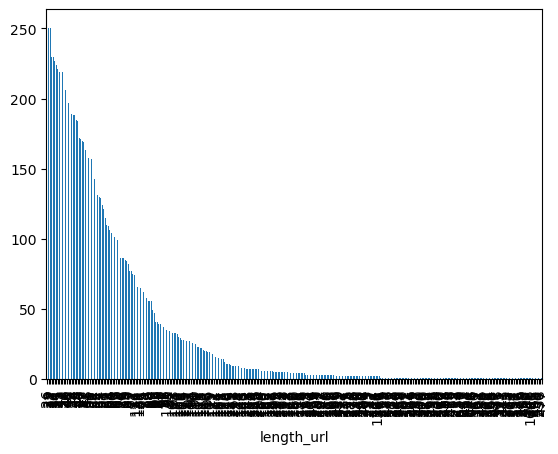

In [76]:
df['length_url'].value_counts().plot(kind='bar')
plt.show()

### Questão 2

Crie um histograma.

In [83]:
df['length_url'].plot(kind='hist', by='status')
plt.show()

KeyError: 'status'

### Questão 3

Crie um gráfico de dispersão.

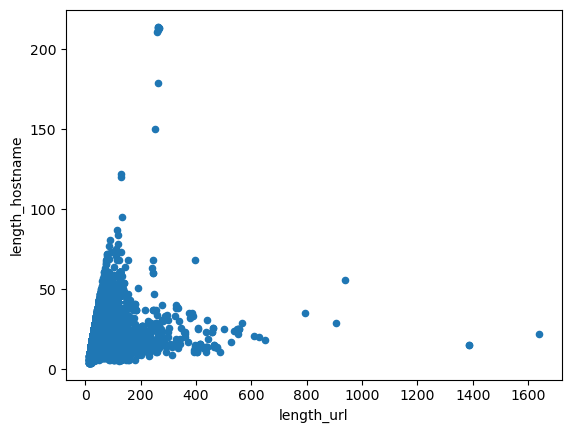

In [80]:
df.plot.scatter(x='length_url', y='length_hostname')
plt.show()

### Questão 4

Crie um boxplot.

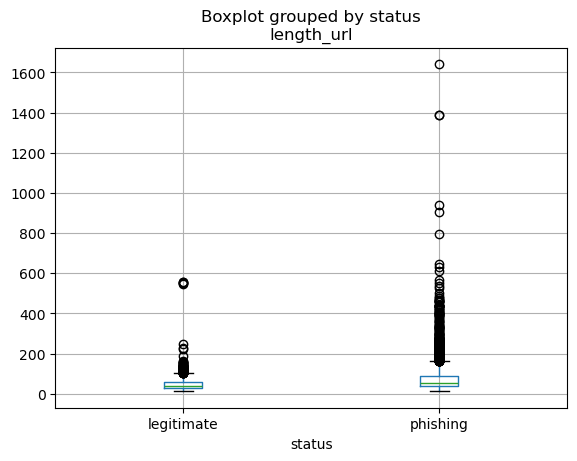

In [82]:
df.boxplot(column='length_url', by="status")
plt.show()

### Questão 5

Escolha o gráfico mais adequado para representar os dados.

O gráfico mais adequado é


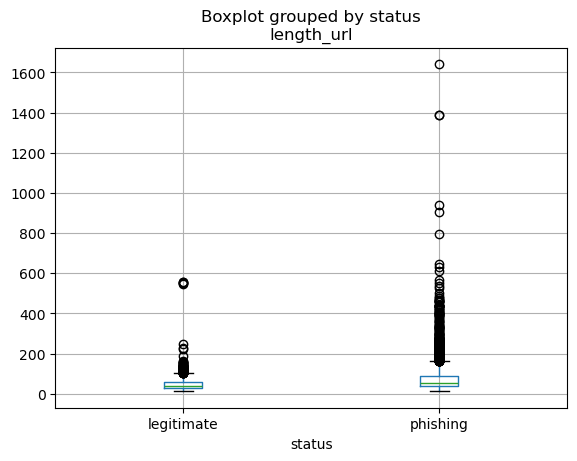

In [85]:
print('O gráfico mais adequado é')
df.boxplot(column='length_url', by="status")
plt.show()